# Combine PTV Uniform Background Summary
Load the per-experiment `ptv_uniform_background_summary.csv` files so they can be plotted in the next cells.


In [3]:
import pandas as pd
import yaml
from pathlib import Path
from IPython.display import display

REPO_ROOT = Path('..').resolve()
if not (REPO_ROOT / '.git').exists():
    REPO_ROOT = REPO_ROOT.parent
CONFIG_DIR = REPO_ROOT / 'configs'
SUMMARY_NAME = 'ptv_uniform_background_summary.csv'


def resolve_path(path_like, base_dir: Path) -> Path:
    candidate = Path(path_like)
    return candidate if candidate.is_absolute() else (base_dir / candidate).resolve()


aggregated = []
for cfg_path in sorted(CONFIG_DIR.glob('*.yaml')):
    try:
        config = yaml.safe_load(cfg_path.read_text(encoding='utf-8')) or {}
    except Exception as exc:
        print('failed to read', cfg_path.name, exc)
        continue
    input_cfg = config.get('input', {})
    base_raw = input_cfg.get('base_dir')
    if not base_raw:
        continue
    base_dir = resolve_path(base_raw, cfg_path.parent)
    raw_root_candidate = input_cfg.get('raw_root')
    raw_root = resolve_path(raw_root_candidate or base_dir.parent, cfg_path.parent)
    processed_root_candidate = input_cfg.get('processed_root')
    fallback = raw_root.parent / 'processed'
    processed_root = resolve_path(processed_root_candidate or fallback, cfg_path.parent)
    try:
        relative = base_dir.relative_to(raw_root)
    except ValueError:
        relative = Path(base_dir.name)
    processed_experiment = processed_root / relative
    summary_path = processed_experiment / 'ptv_uniform_background' / SUMMARY_NAME
    if not summary_path.exists():
        continue
    df = pd.read_csv(summary_path)
    df['config'] = cfg_path.name
    df['experiment_dir'] = processed_experiment.name
    df['processed_path'] = str(processed_experiment)
    aggregated.append(df)

if aggregated:
    global_ptv_summary = pd.concat(aggregated, ignore_index=True)
    display(global_ptv_summary.head())
else:
    global_ptv_summary = pd.DataFrame()
    print('No PTV uniform background summaries were found to concatenate.')


,subfolder,threshold_value,frame_rate_hz,pixelperum,mean_speed_um_per_s,std_speed_um_per_s,n_particles,mean_vx_um_per_s,std_vx_um_per_s,mean_vy_um_per_s,std_vy_um_per_s,overlay_path,particle_type,particle_diameter_um,experiment,config,experiment_dir,processed_path
0,0,88,22.0000,1.36,290.084147,29.963392,40,-29.728720,7.589997,-288.440415,30.150641,/Volumes/Extreme SSD/deep-sea-particles-gm/pro...,pyrite,45.284953,pyrite_2024-11-14 20-00-15.825503_good,opencv_tracker_v3.yaml,pyrite_2024-11-14 20-00-15.825503_good,/Volumes/Extreme SSD/deep-sea-particles-gm/pro...
1,0,74,17.8000,1.36,36.535743,1.577480,11,1.060838,0.677289,-36.514821,1.572584,/Volumes/Extreme SSD/deep-sea-particles-gm/pro...,plume particle,35.186869,particle_1_2024-11-14 15-50-7.516153,particle_1_2024-11-14_15-50-7_516153.yaml,particle_1_2024-11-14 15-50-7.516153,/Volumes/Extreme SSD/deep-sea-particles-gm/pro...
2,0,63,15.9500,1.36,103.801369,28.171085,3,0.294134,3.562564,-103.764591,28.146745,/Volumes/Extreme SSD/deep-sea-particles-gm/pro...,plume particle,37.817537,particle_2024-11-14 15-31-17.234515,particle_2024-11-14_15-31-17_234515.yaml,particle_2024-11-14 15-31-17.234515,/Volumes/Extreme SSD/deep-sea-particles-gm/pro...
3,0,74,13.2500,1.36,87.521620,18.160551,8,-0.728538,2.033288,-87.494722,18.178142,/Volumes/Extreme SSD/deep-sea-particles-gm/pro...,plume particle,37.745066,particle_2024-11-14 15-44-57.488742,particle_2024-11-14_15-44-57_488742.yaml,particle_2024-11-14 15-44-57.488742,/Volumes/Extreme SSD/deep-sea-particles-gm/pro...
4,0,70,16.5625,1.36,103.118577,9.698694,7,-0.839551,3.246059,-103.068643,9.732278,/Volumes/Extreme SSD/deep-sea-particles-gm/pro...,plume particle,36.471238,particle_2024-11-14 15-45-42.416116,particle_2024-11-14_15-45-42_416116.yaml,particle_2024-11-14 15-45-42.416116,/Volumes/Extreme SSD/deep-sea-particles-gm/pro...


In [4]:
import sys
sys.path.insert(0, str(REPO_ROOT))
from plots_style import use_fl_style
use_fl_style()


In [5]:
global_ptv_summary

,subfolder,threshold_value,frame_rate_hz,pixelperum,mean_speed_um_per_s,std_speed_um_per_s,n_particles,mean_vx_um_per_s,std_vx_um_per_s,mean_vy_um_per_s,std_vy_um_per_s,overlay_path,particle_type,particle_diameter_um,experiment,config,experiment_dir,processed_path
0,0,88,22.000000,1.36,290.084147,29.963392,40,-29.728720,7.589997,-288.440415,30.150641,/Volumes/Extreme SSD/deep-sea-particles-gm/pro...,pyrite,45.284953,pyrite_2024-11-14 20-00-15.825503_good,opencv_tracker_v3.yaml,pyrite_2024-11-14 20-00-15.825503_good,/Volumes/Extreme SSD/deep-sea-particles-gm/pro...
1,0,74,17.800000,1.36,36.535743,1.577480,11,1.060838,0.677289,-36.514821,1.572584,/Volumes/Extreme SSD/deep-sea-particles-gm/pro...,plume particle,35.186869,particle_1_2024-11-14 15-50-7.516153,particle_1_2024-11-14_15-50-7_516153.yaml,particle_1_2024-11-14 15-50-7.516153,/Volumes/Extreme SSD/deep-sea-particles-gm/pro...
2,0,63,15.950000,1.36,103.801369,28.171085,3,0.294134,3.562564,-103.764591,28.146745,/Volumes/Extreme SSD/deep-sea-particles-gm/pro...,plume particle,37.817537,particle_2024-11-14 15-31-17.234515,particle_2024-11-14_15-31-17_234515.yaml,particle_2024-11-14 15-31-17.234515,/Volumes/Extreme SSD/deep-sea-particles-gm/pro...
3,0,74,13.250000,1.36,87.521620,18.160551,8,-0.728538,2.033288,-87.494722,18.178142,/Volumes/Extreme SSD/deep-sea-particles-gm/pro...,plume particle,37.745066,particle_2024-11-14 15-44-57.488742,particle_2024-11-14_15-44-57_488742.yaml,particle_2024-11-14 15-44-57.488742,/Volumes/Extreme SSD/deep-sea-particles-gm/pro...
4,0,70,16.562500,1.36,103.118577,9.698694,7,-0.839551,3.246059,-103.068643,9.732278,/Volumes/Extreme SSD/deep-sea-particles-gm/pro...,plume particle,36.471238,particle_2024-11-14 15-45-42.416116,particle_2024-11-14_15-45-42_416116.yaml,particle_2024-11-14 15-45-42.416116,/Volumes/Extreme SSD/deep-sea-particles-gm/pro...
5,1,89,16.800000,1.36,38.849156,5.329628,10,-8.840971,7.930765,-37.119083,4.969343,/Volumes/Extreme SSD/deep-sea-particles-gm/pro...,plume particle,23.058262,particle_2_2024-11-14 15-55-5.076280,particle_2_2024-11-14_15-55-5_076280.yaml,particle_2_2024-11-14 15-55-5.076280,/Volumes/Extreme SSD/deep-sea-particles-gm/pro...
6,2,90,16.083333,1.36,34.000042,4.778501,13,0.275807,3.251855,-33.849407,4.821748,/Volumes/Extreme SSD/deep-sea-particles-gm/pro...,plume particle,23.391287,particle_2_2024-11-14 15-55-5.076280,particle_2_2024-11-14_15-55-5_076280.yaml,particle_2_2024-11-14 15-55-5.076280,/Volumes/Extreme SSD/deep-sea-particles-gm/pro...
7,0,79,16.666667,1.36,94.269874,3.819944,22,-3.736270,1.658314,-94.181997,3.816634,/Volumes/Extreme SSD/deep-sea-particles-gm/pro...,plume particle,37.644044,plume_particle_2_2024-11-14 17-39-37.245115,plume_particle_2_2024-11-14_17-39-37_245115.yaml,plume_particle_2_2024-11-14 17-39-37.245115,/Volumes/Extreme SSD/deep-sea-particles-gm/pro...
8,0,68,19.142857,1.36,179.668949,64.316157,4,-20.891327,21.615356,-178.048833,62.130027,/Volumes/Extreme SSD/deep-sea-particles-gm/pro...,plume particle,44.737645,plume_particle_3_2024-11-14 17-51-12.608197,plume_particle_3_2024-11-14_17-51-12_608197.yaml,plume_particle_3_2024-11-14 17-51-12.608197,/Volumes/Extreme SSD/deep-sea-particles-gm/pro...
9,1,53,16.888889,2.40,31.635391,1.750886,14,-1.445949,0.802306,-31.591973,1.768230,/Volumes/Extreme SSD/deep-sea-particles-gm/pro...,plume particle,26.104175,plume_particle_4_20x_2024-11-14 18-04-9.185642,plume_particle_4_20x_2024-11-14_18-04-9_185642...,plume_particle_4_20x_2024-11-14 18-04-9.185642,/Volumes/Extreme SSD/deep-sea-particles-gm/pro...


In [6]:
# No:of particles of each type
global_ptv_summary['particle_type'].value_counts()

particle_type
plume particle    11
pyrite             2
Name: count, dtype: int64

# Plots



In [7]:
figures_path = '/Users/deepak/Library/CloudStorage/Dropbox/Postdoc_Berkeley/FletcherLab/Projects/deep-sea-particles/figures'

if not Path(figures_path).exists():
    Path(figures_path).mkdir(parents=True, exist_ok=True)

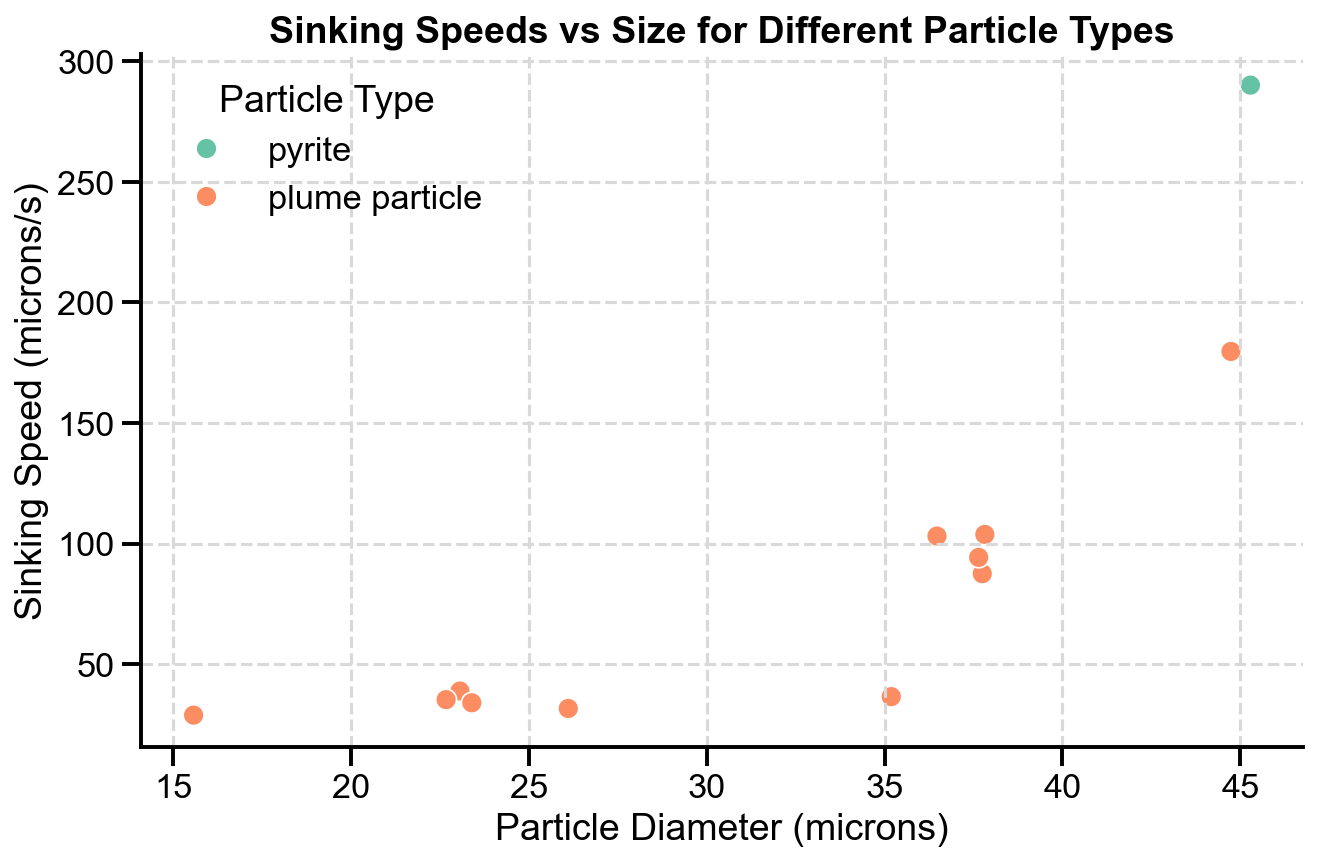

In [8]:
# Plot the sinking speeds vs size for each particle type
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('talk')
%matplotlib inline


x_axis = 'particle_diameter_um'
y_axis = 'mean_speed_um_per_s'

plt.figure(figsize=(10, 6))
sns.scatterplot(data=global_ptv_summary, x=x_axis, y=y_axis, hue='particle_type', palette='Set2', s=100)
plt.title('Sinking Speeds vs Size for Different Particle Types')
plt.xlabel('Particle Diameter (microns)')
plt.ylabel('Sinking Speed (microns/s)')
plt.legend(title='Particle Type')
# plt.savefig(Path(figures_path) / 'sinking_speeds_vs_size.png', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/20/2mwnmt_d7s9gxq4gx2z2nfmc0000gn/T/ipykernel_71836/4050677911.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=global_ptv_summary, x='particle_type', y='mean_speed_um_per_s', palette='Set2')


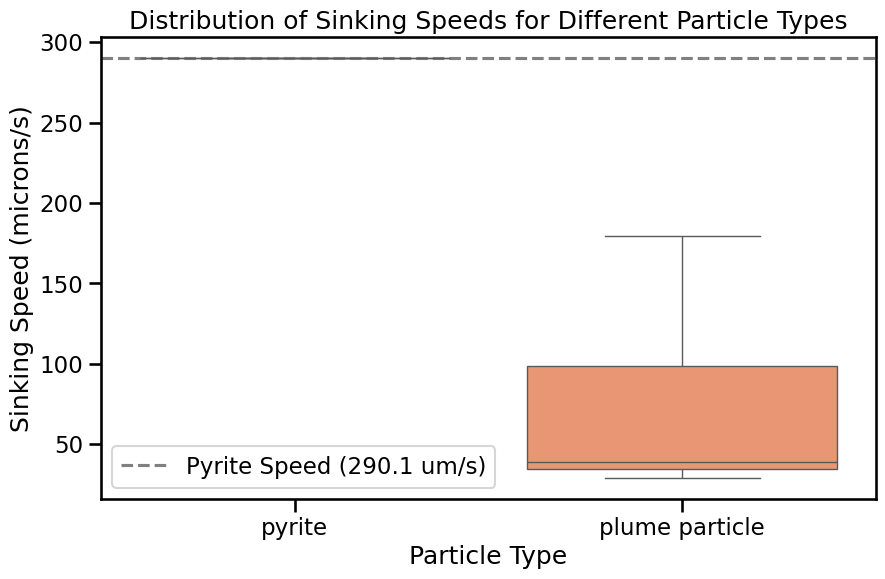

In [6]:
# Plot as boxplot to show distribution of sinking speeds for each particle type
plt.figure(figsize=(10, 6))
sns.boxplot(data=global_ptv_summary, x='particle_type', y='mean_speed_um_per_s', palette='Set2')

# show a horizontal line at the 'pyrite' sinking speed for reference
pyrite_speed = global_ptv_summary[global_ptv_summary['particle_type'] == 'pyrite']['mean_speed_um_per_s'].values[0]
plt.axhline(pyrite_speed, color='gray', linestyle='--', label=f'Pyrite Speed ({pyrite_speed:.1f} um/s)')
plt.legend()

plt.title('Distribution of Sinking Speeds for Different Particle Types')
plt.xlabel('Particle Type')
plt.ylabel('Sinking Speed (microns/s)')
plt.savefig(Path(figures_path) / 'sinking_speed_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [25]:
# Rescale sinking speeds by particle diameter to see if they collapse onto a single curve
global_ptv_summary['speed_per_diameter^2'] = global_ptv_summary['mean_speed_um_per_s'] / (global_ptv_summary['particle_diameter_um']**2)

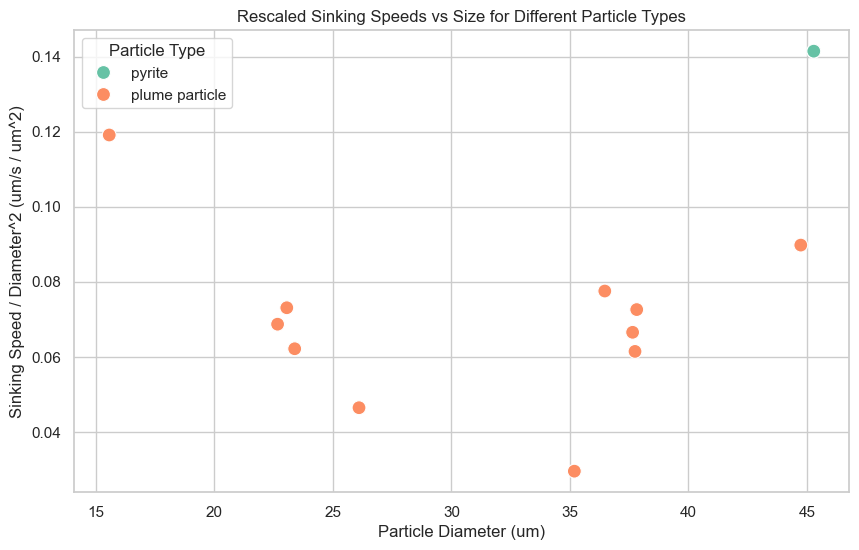

In [26]:
# Plot the rescaled sinking speeds vs size for each particle type
plt.figure(figsize=(10, 6))
sns.scatterplot(data=global_ptv_summary, x=x_axis, y='speed_per_diameter^2', hue='particle_type', palette='Set2', s=100)
plt.title('Rescaled Sinking Speeds vs Size for Different Particle Types')
plt.xlabel('Particle Diameter (um)')
plt.ylabel('Sinking Speed / Diameter^2 (um/s / um^2)')
plt.legend(title='Particle Type')
plt.show()

In [12]:
# Estimate the excess density using Stokes' law: v = (2/9) * (rho_particle - rho_fluid) * g * r^2 / mu
# where v is the sinking speed, rho_particle is the particle density, rho_fluid is the fluid density, g is the gravitational acceleration, r is the particle radius, and mu is the
# fluid viscosity. Rearranging gives: rho_particle - rho_fluid = (9/2) * v * mu / (g * r^2)
g = 9.81  # gravitational acceleration in m/s^2
mu = 0.001  # dynamic viscosity of water in Pa.s
global_ptv_summary['excess_density'] = 6 * global_ptv_summary['mean_speed_um_per_s']*1e-6 * mu / (g * (global_ptv_summary['particle_diameter_um']*1e-6)**2)  # convert diameter from um to m for radius in m^2



/var/folders/20/2mwnmt_d7s9gxq4gx2z2nfmc0000gn/T/ipykernel_53787/3264694178.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Particle Type')


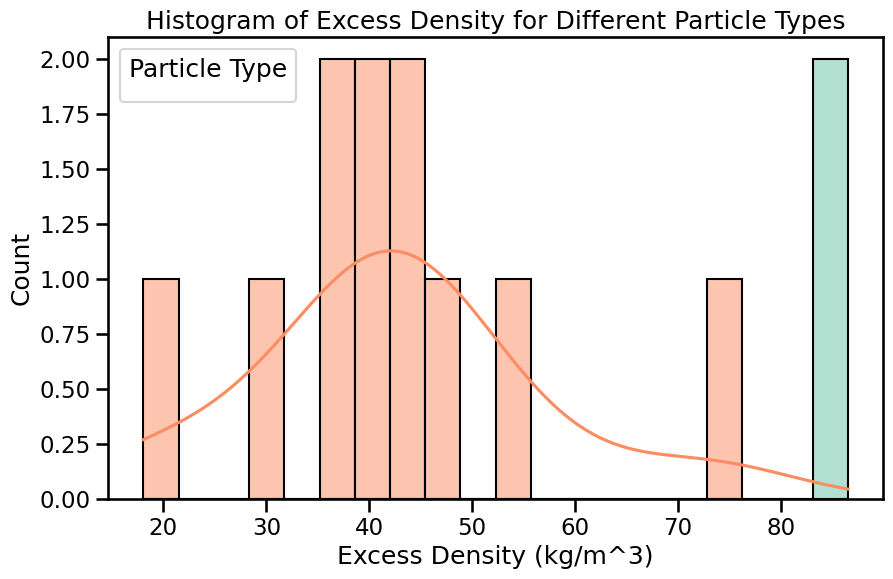

In [14]:
# Plot the excess density as a histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=global_ptv_summary, x='excess_density', hue='particle_type', palette='Set2', bins=20, kde=True)
plt.title('Histogram of Excess Density for Different Particle Types')
plt.xlabel('Excess Density (kg/m^3)')
plt.ylabel('Count')
plt.legend(title='Particle Type')
plt.savefig(Path(figures_path) / 'excess_density_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

plume particle: excess density = 128.62 ± 10.45 kg/m^3
pyrite: excess density = 259.55 ± 0.00 kg/m^3


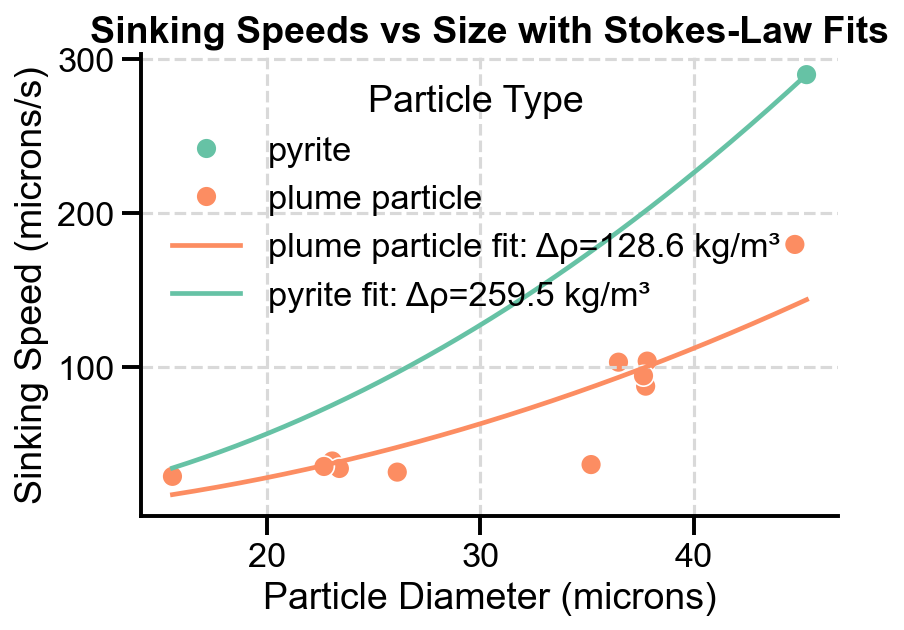

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit

# --- constants ---
g = 9.81                  # m/s^2
mu = 1.0e-3               # Pa.s = kg/(m s), approximate for water at room temp

# Stokes-law model
# Input diameter in microns, output speed in microns/s
def stokes_speed_um_per_s(d_um, delta_rho):
    d_m = d_um * 1e-6
    v_m_per_s = (delta_rho * g * d_m**2) / (18 * mu)
    v_um_per_s = v_m_per_s * 1e6
    return v_um_per_s

colors = sns.color_palette('Set2', n_colors=global_ptv_summary['particle_type'].nunique())

# Fit excess density for each particle type
fit_results = {}

for particle_type, group in global_ptv_summary.groupby('particle_type'):
    x_data = group['particle_diameter_um'].to_numpy()
    y_data = group['mean_speed_um_per_s'].to_numpy()

    # keep only finite, positive values
    mask = np.isfinite(x_data) & np.isfinite(y_data) & (x_data > 0) & (y_data > 0)
    x_data = x_data[mask]
    y_data = y_data[mask]

    if len(x_data) < 2:
        print(f'Not enough data to fit {particle_type}')
        continue

    try:
        # initial guess: 50 kg/m^3 excess density
        popt, pcov = curve_fit(
            stokes_speed_um_per_s,
            x_data,
            y_data,
            p0=[50.0],
            bounds=(0, np.inf)
        )
        delta_rho_fit = popt[0]
        delta_rho_se = np.sqrt(np.diag(pcov))[0] if pcov.size else np.nan

        fit_results[particle_type] = {
            "delta_rho_kg_m3": delta_rho_fit,
            "delta_rho_se_kg_m3": delta_rho_se
        }

        print(
            f"{particle_type}: "
            f"excess density = {delta_rho_fit:.2f} ± {delta_rho_se:.2f} kg/m^3"
        )

    except Exception as exc:
        print(f'Failed to fit Stokes law for {particle_type}: {exc}')

# Plot data and fitted Stokes curves
plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=global_ptv_summary,
    x='particle_diameter_um',
    y='mean_speed_um_per_s',
    hue='particle_type',
    palette=colors,
    s=100
)

x_fit = np.linspace(
    global_ptv_summary['particle_diameter_um'].min(),
    global_ptv_summary['particle_diameter_um'].max(),
    200
)

for particle_type, result in fit_results.items():
    delta_rho_fit = result["delta_rho_kg_m3"]
    y_fit = stokes_speed_um_per_s(x_fit, delta_rho_fit)
    plt.plot(
        x_fit,
        y_fit,
        label=f"{particle_type} fit: Δρ={delta_rho_fit:.1f} kg/m³",
        color=colors[global_ptv_summary['particle_type'].unique().tolist().index(particle_type)]
    )

plt.title('Sinking Speeds vs Size with Stokes-Law Fits')
plt.xlabel('Particle Diameter (microns)')
plt.ylabel('Sinking Speed (microns/s)')
plt.legend(title='Particle Type')
plt.savefig(Path(figures_path) / 'sinking_speeds_vs_size_with_fits.png', dpi=300, bbox_inches='tight')
plt.savefig(Path(figures_path) / 'sinking_speeds_vs_size_with_fits.svg', dpi=300, bbox_inches='tight')

plt.show()

In [18]:
# Find particles in different sinking speed ranges
slow_particles = global_ptv_summary[global_ptv_summary['mean_speed_um_per_s'] < 50]
medium_particles = global_ptv_summary[(global_ptv_summary['mean_speed_um_per_s'] >= 50) & (global_ptv_summary['mean_speed_um_per_s'] < 200)]
fast_particles = global_ptv_summary[global_ptv_summary['mean_speed_um_per_s'] >= 200]

In [20]:
# print experiment directories for each speed category
print("Slow particles (<50 um/s):")
print(slow_particles['processed_path'].unique())
print("\nMedium particles (50-200 um/s):")
print(medium_particles['processed_path'].unique())
print("\nFast particles (>200 um/s):")
print(fast_particles['processed_path'].unique())


Slow particles (<50 um/s):
<StringArray>
[           '/Volumes/Extreme SSD/deep-sea-particles-gm/processed/particle_1_2024-11-14 15-50-7.516153',
            '/Volumes/Extreme SSD/deep-sea-particles-gm/processed/particle_2_2024-11-14 15-55-5.076280',
  '/Volumes/Extreme SSD/deep-sea-particles-gm/processed/plume_particle_4_20x_2024-11-14 18-04-9.185642',
  '/Volumes/Extreme SSD/deep-sea-particles-gm/processed/plume_particle_5_20x_2024-11-14 18-07-1.225042',
 '/Volumes/Extreme SSD/deep-sea-particles-gm/processed/plume_particle_6_20x_2024-11-14 18-09-41.970098']
Length: 5, dtype: str

Medium particles (50-200 um/s):
<StringArray>
[        '/Volumes/Extreme SSD/deep-sea-particles-gm/processed/particle_2024-11-14 15-31-17.234515',
         '/Volumes/Extreme SSD/deep-sea-particles-gm/processed/particle_2024-11-14 15-44-57.488742',
         '/Volumes/Extreme SSD/deep-sea-particles-gm/processed/particle_2024-11-14 15-45-42.416116',
 '/Volumes/Extreme SSD/deep-sea-particles-gm/processed/plume_p

In [21]:
# Find largest particle in each speed category
largest_slow = slow_particles.loc[slow_particles['particle_diameter_um'].idxmax()]
largest_medium = medium_particles.loc[medium_particles['particle_diameter_um'].idxmax()]
largest_fast = fast_particles.loc[fast_particles['particle_diameter_um'].idxmax()]

In [24]:
print("\nLargest slow particle:")
print(largest_slow['processed_path'])
print("\nLargest medium particle:")
print(largest_medium[['processed_path', 'particle_diameter_um', 'mean_speed_um_per_s']])
print("\nLargest fast particle:")
print(largest_fast[['processed_path', 'particle_diameter_um', 'mean_speed_um_per_s']])  



Largest slow particle:
/Volumes/Extreme SSD/deep-sea-particles-gm/processed/particle_1_2024-11-14 15-50-7.516153

Largest medium particle:
processed_path          /Volumes/Extreme SSD/deep-sea-particles-gm/pro...
particle_diameter_um                                            44.737645
mean_speed_um_per_s                                            179.668949
Name: 8, dtype: object

Largest fast particle:
processed_path          /Volumes/Extreme SSD/deep-sea-particles-gm/pro...
particle_diameter_um                                            45.284953
mean_speed_um_per_s                                            290.084147
Name: 0, dtype: object
